# RL co-design results and distribution convergence

It compares training metrics, validation results, design trajectories and the marginal pre-clipping mixture densities for PV and battery capacity. Before using this, run the experiment from the repo's root using:

```bash
python train_rl.py --model all --log-every 10 --output-directory runs/
```

In [28]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()

RUN_ROOT = REPO_ROOT / "runs"
RUN_ROOT

PosixPath('/Users/shreyansjain/Desktop/ReiforcementLearning/Co-Design-RL/runs')

In [29]:
def load_run(model_directory):
    with (model_directory / "validation.json").open() as file:
        validation = json.load(file)
    with (model_directory / "configuration.json").open() as file:
        configuration = json.load(file)
    return {
        "training": pd.read_csv(model_directory / "training.csv"),
        "samples": pd.read_csv(model_directory / "training_samples.csv"),
        "distribution": pd.read_csv(
            model_directory / "design_distribution.csv"
        ),
        "validation": validation,
        "configuration": configuration,
    }

model_directories = sorted(path for path in RUN_ROOT.iterdir() if path.is_dir())
if not model_directories:
    raise FileNotFoundError(f"No model results found under {RUN_ROOT}")

runs = {path.name: load_run(path) for path in model_directories}
list(runs)

['ddpg_lognormal', 'ppo_gmm', 'ppo_lognormal']

## Final validation comparison

In [30]:
validation = pd.DataFrame(
    [run["validation"] for run in runs.values()]
).set_index("model")
validation

,split,episodes,sampled_designs,mean_reward_chf,std_reward_chf,mean_cost_chf,mean_pv_capacity_kwp,mean_battery_capacity_kwh,max_power_balance_error_kw
model,,,,,,,,,
ddpg_lognormal,validation,32,False,-107.848618,6.407516,107.848618,0.449528,0.384330,4.440892e-16
ppo_gmm,validation,32,False,-90.095393,7.868302,90.095393,7.005121,2.883790,8.881784e-16
ppo_lognormal,validation,32,False,-92.477896,8.220482,92.477896,6.137049,2.232131,8.881784e-16


## Training and validation curves

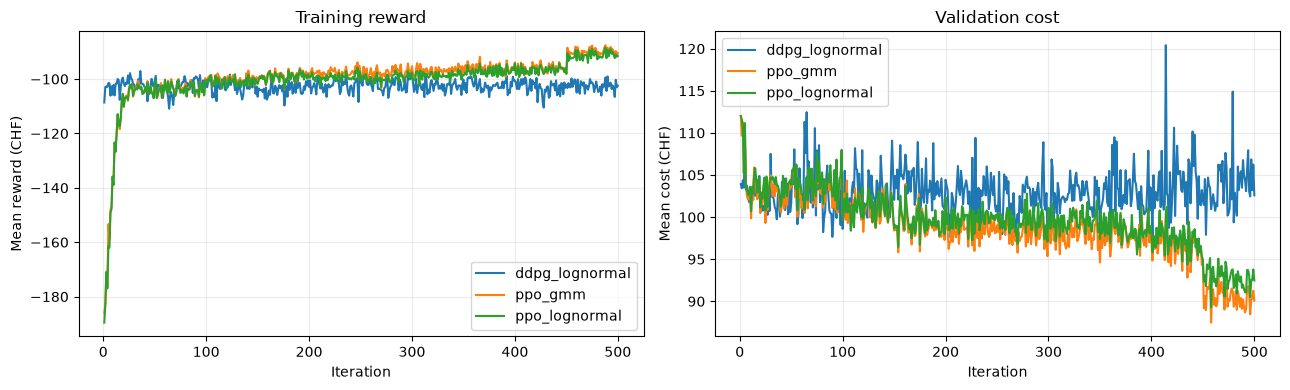

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for model, run in runs.items():
    history = run["training"]
    axes[0].plot(history["iteration"], history["mean_reward_chf"], label=model)
    axes[1].plot(
        history["iteration"],
        history["validation_mean_cost_chf"],
        label=model,
    )
axes[0].set(title="Training reward", xlabel="Iteration", ylabel="Mean reward (CHF)")
axes[1].set(title="Validation cost", xlabel="Iteration", ylabel="Mean cost (CHF)")
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()

## Design trajectory

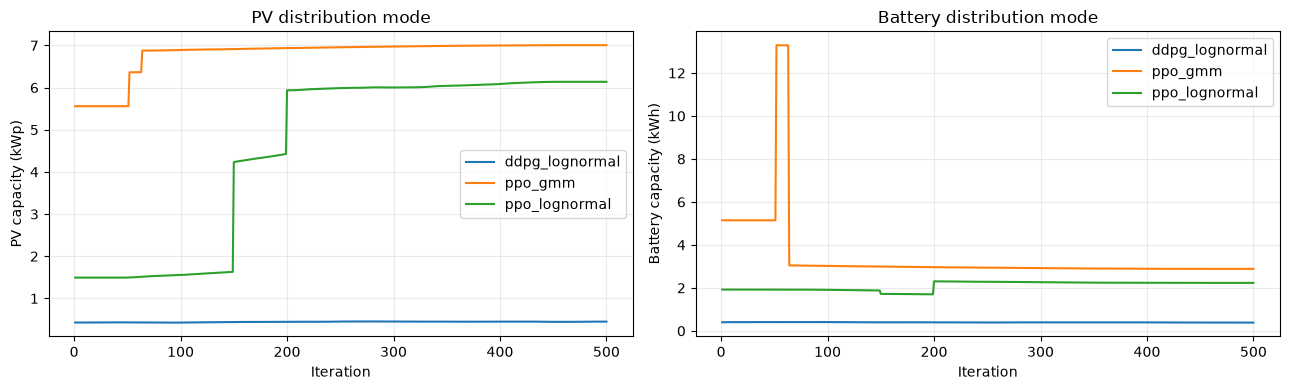

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for model, run in runs.items():
    history = run["training"]
    axes[0].plot(
        history["iteration"], history["mode_pv_capacity_kwp"], label=model
    )
    axes[1].plot(
        history["iteration"],
        history["mode_battery_capacity_kwh"],
        label=model,
    )
axes[0].set(title="PV distribution mode", xlabel="Iteration", ylabel="PV capacity (kWp)")
axes[1].set(title="Battery distribution mode", xlabel="Iteration", ylabel="Battery capacity (kWh)")
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()

## Sampled design convergence

Each dot is the exact PV and battery design used for one training episode. Later panels show whether the sampled designs become more concentrated as learning progresses.

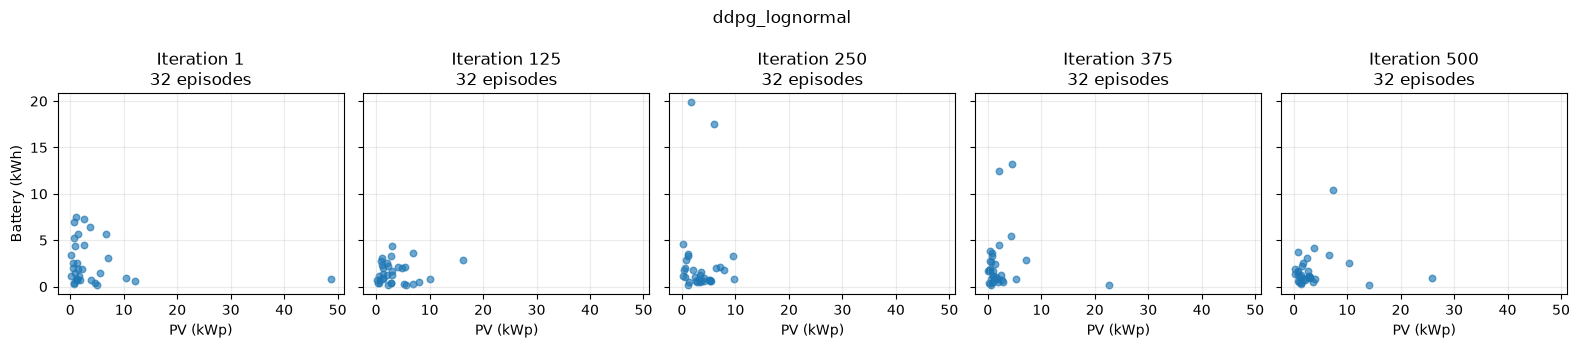

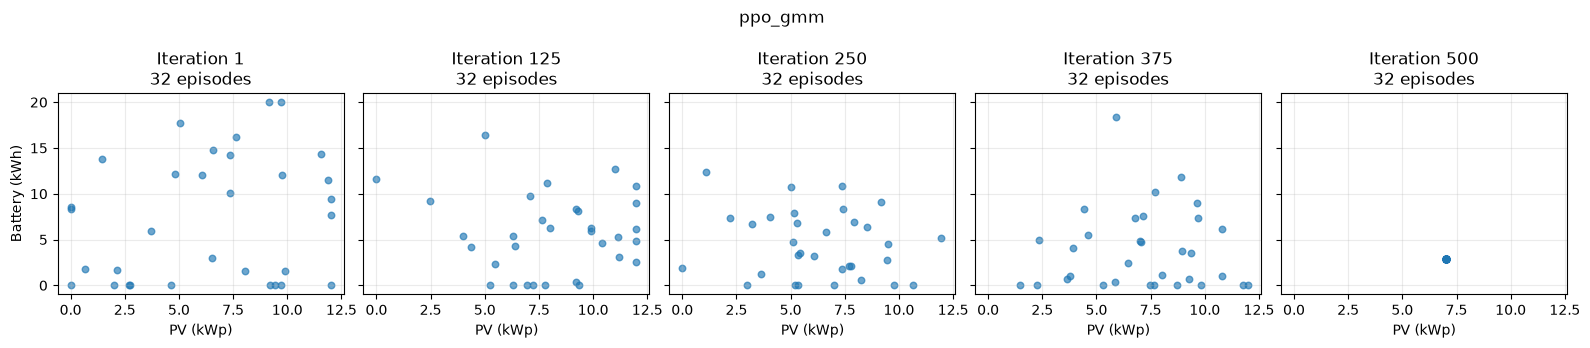

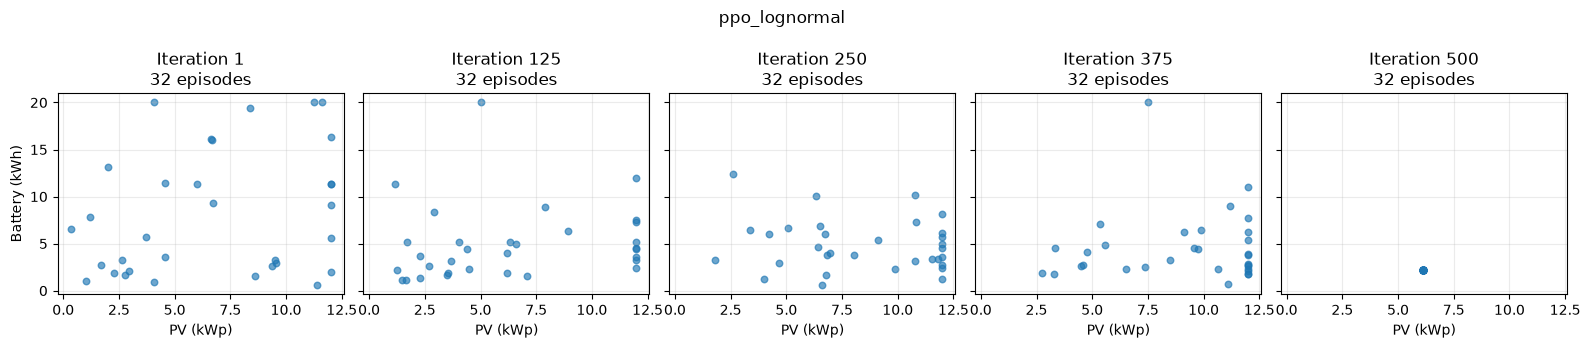

In [33]:
def plot_sample_convergence(model, run):
    samples = run["samples"]
    available = np.sort(samples["iteration"].unique())
    iterations = available[np.linspace(0, len(available) - 1, 5, dtype=int)]
    fig, axes = plt.subplots(1, len(iterations), figsize=(16, 3.5), sharex=True, sharey=True)

    for axis, iteration in zip(axes, iterations):
        selected = samples[samples["iteration"] == iteration]
        axis.scatter(selected["pv_capacity_kwp"], selected["battery_capacity_kwh"], s=22, alpha=0.65)
        axis.set(title=f"Iteration {iteration}\n{len(selected)} episodes", xlabel="PV (kWp)")
        axis.grid(alpha=0.25)

    axes[0].set_ylabel("Battery (kWh)")
    fig.suptitle(model)
    plt.tight_layout()


for model, run in runs.items():
    plot_sample_convergence(model, run)

## Probability-distribution convergence

These curves show the learned distributions before design limits are applied. Gaussian values use physical units, while log-normal values use log-space. Clipping may concentrate some probability at the limits

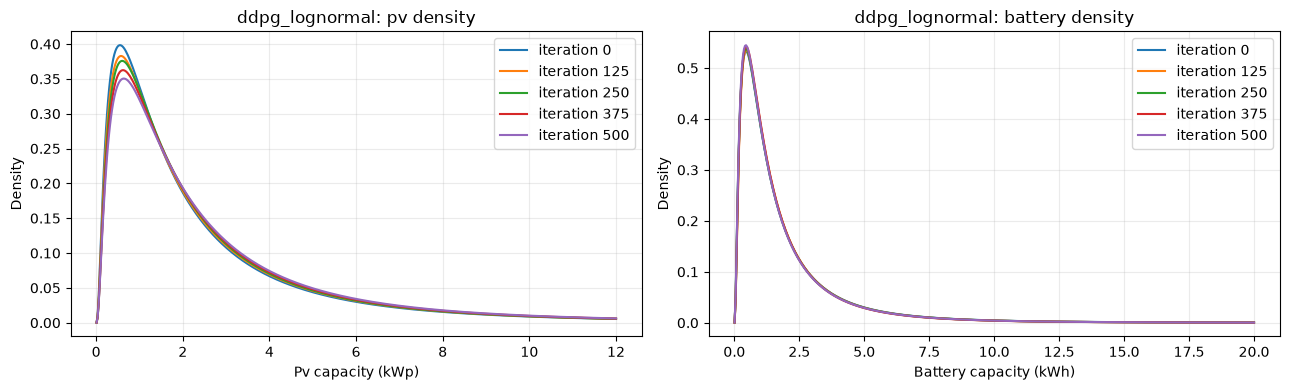

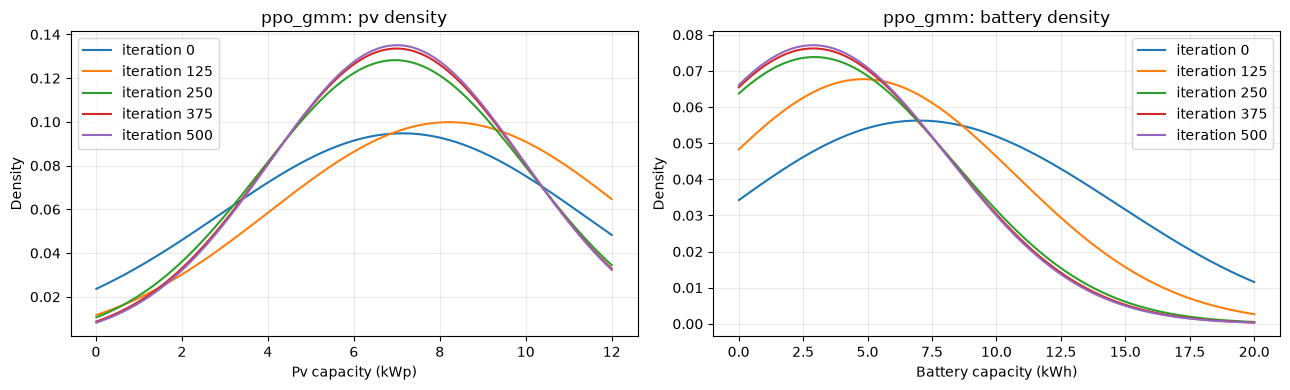

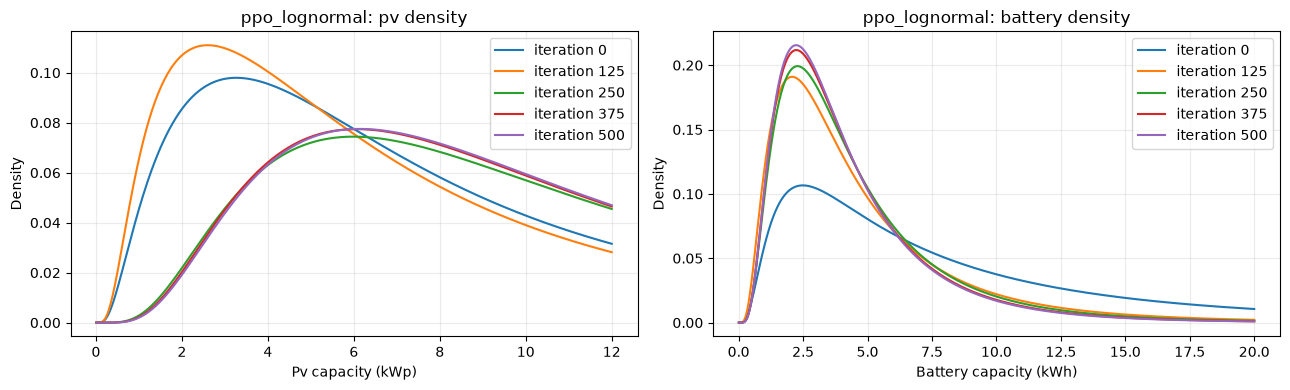

In [34]:
def selected_iterations(distribution_history, maximum_curves=5):
    iterations = np.sort(distribution_history["iteration"].unique())
    count = min(maximum_curves, len(iterations))
    indices = np.linspace(0, len(iterations) - 1, count, dtype=int)
    return np.unique(iterations[indices])


def mixture_pdf(snapshot, dimension, grid):
    locations = snapshot[f"{dimension}_location"].to_numpy()[:, None]
    scales = snapshot[f"{dimension}_scale"].to_numpy()[:, None]
    weights = snapshot["weight"].to_numpy()[:, None]

    if snapshot["distribution"].iloc[0] == "gaussian":
        component_pdf = np.exp(-0.5 * ((grid - locations) / scales) ** 2)
        component_pdf /= scales * np.sqrt(2.0 * np.pi)
    else:
        positive_grid = np.maximum(grid, 1e-12)
        component_pdf = np.exp(
            -0.5 * ((np.log(positive_grid) - locations) / scales) ** 2
        )
        component_pdf /= positive_grid * scales * np.sqrt(2.0 * np.pi)

    return (weights * component_pdf).sum(axis=0)


def plot_distribution_convergence(model, run):
    distribution_history = run["distribution"]
    grids = {
        "pv": np.linspace(0.01, 12.0, 500),
        "battery": np.linspace(0.01, 20.0, 500),
    }
    units = {"pv": "kWp", "battery": "kWh"}
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for axis, dimension in zip(axes, ("pv", "battery")):
        grid = grids[dimension]
        for iteration in selected_iterations(distribution_history):
            snapshot = distribution_history[
                distribution_history["iteration"] == iteration
            ]
            axis.plot(
                grid,
                mixture_pdf(snapshot, dimension, grid),
                label=f"iteration {iteration}",
            )
        axis.set(
            title=f"{model}: {dimension} density",
            xlabel=f"{dimension.title()} capacity ({units[dimension]})",
            ylabel="Density",
        )
        axis.grid(alpha=0.25)
        axis.legend()

    plt.tight_layout()


for model, run in runs.items():
    plot_distribution_convergence(model, run)

## Final mixture-component parameters

In [35]:
final_components = []
for model, run in runs.items():
    distribution_history = run["distribution"]
    final_iteration = distribution_history["iteration"].max()
    final_components.append(
        distribution_history[
            distribution_history["iteration"] == final_iteration
        ]
    )
pd.concat(final_components, ignore_index=True)

,iteration,model,distribution,parameter_space,component,active,weight,pv_location,pv_scale,battery_location,battery_scale
0,500,ddpg_lognormal,lognormal,log,0,True,0.321100,0.556849,0.977823,0.166307,0.995489
1,500,ddpg_lognormal,lognormal,log,1,True,0.366887,0.990039,0.949677,0.327390,0.993761
2,500,ddpg_lognormal,lognormal,log,2,True,0.312013,0.235014,1.017139,0.045521,1.000887
3,500,ppo_gmm,gaussian,physical,0,False,0.000000,5.616762,3.326230,5.083303,5.683696
4,500,ppo_gmm,gaussian,physical,1,False,0.000000,10.037870,3.367513,7.474508,5.713757
5,500,ppo_gmm,gaussian,physical,2,False,0.000000,2.654533,3.430384,3.344914,5.702354
6,500,ppo_gmm,gaussian,physical,3,True,1.000000,7.005121,2.953906,2.883790,5.173326
7,500,ppo_gmm,gaussian,physical,4,False,0.000000,8.372244,3.426696,11.971019,5.743864
8,500,ppo_gmm,gaussian,physical,5,False,0.000000,10.165453,3.351380,4.045503,5.445048
9,500,ppo_gmm,gaussian,physical,6,False,0.000000,6.206274,3.387012,10.503533,5.752316
